In [ ]:
import pandas as pd
import numpy as np
import gurobipy as gp
from gurobipy import GRB
import pandas as pd


In [ ]:

fname = "customers.xlsx" 
df_nodes = pd.read_excel(fname, sheet_name=0, engine='openpyxl')
df_requests = pd.read_excel(fname, sheet_name=1, engine='openpyxl')
df_Fleet = pd.read_excel(fname, sheet_name=2, engine='openpyxl')



df_nodes.head()
df_requests.head()

n_customers = 25
df_nodes = df_nodes[df_nodes['id'] <= n_customers].copy()

In [ ]:
nodes = df_nodes.copy()

In [ ]:
coords = nodes[['cx', 'cy']].values
ids = nodes['id'].values

n_nodes = len(ids)
n_nodes

In [ ]:
import matplotlib.pyplot as plt
from gurobipy import GRB

def plot_tsp_tour(model, df_nodes, x, n_nodes, coords):
    """
    Plots the optimal TSP tour based on Gurobi model output.
    
    Args:
        model: The solved Gurobi model object.
        df_nodes: DataFrame containing columns 'cx', 'cy', and 'id'.
        x: The Gurobi decision variables (x[i,j]).
        n_nodes: The number of nodes/cities in the problem (including depot).
        coords: A list or array of coordinates [[x, y], ...] corresponding to nodes.
    """
    if model.status == GRB.OPTIMAL:
        plt.figure(figsize=(8, 8))
        
        # --- 1. Plot Nodes ---
        # Slice the dataframe to only include the nodes involved in this run (0 to n_nodes)
        subset = df_nodes.iloc[:n_nodes]
        
        # Plot Customers (indices 1 to n_nodes-1)
        # We assume row 0 is the depot, so we plot rows 1 onwards from the subset
        if n_nodes > 1:
            plt.scatter(subset.iloc[1:]['cx'], subset.iloc[1:]['cy'], c='blue', label='Customers')
        
        # Plot Depot (Node 0) in Red
        plt.scatter(subset.iloc[0]['cx'], subset.iloc[0]['cy'], c='red', s=100, label='Depot')

        # --- 2. Draw Arrows ---
        # Loop through every potential connection x[i,j]
        for i in range(n_nodes):
            for j in range(n_nodes):
                # Check if the solver selected this edge (value approx 1.0)
                if i != j and x[i, j].X > 0.5:
                    # Get coordinates for city i (start) and city j (end)
                    x1, y1 = coords[i][0], coords[i][1]
                    x2, y2 = coords[j][0], coords[j][1]
                    
                    # Draw arrow
                    plt.arrow(x1, y1, x2-x1, y2-y1, 
                              head_width=0.1, length_includes_head=True, 
                              color='black', alpha=0.7)

        # --- 3. Add Labels ---
        for i, row in subset.iterrows():
            plt.text(row['cx']+0.5, row['cy']+0.5, str(int(row['id'])), fontsize=12)

        # --- 4. Finalize Plot ---
        plt.title(f"Optimal TSP Tour (Distance: {model.objVal:.2f})")
        plt.legend()
        plt.grid(True)
        plt.show()
        
    else:
        print("Model solution is not optimal. Cannot plot.")

In [ ]:
def test_tour():
    coords_sq = np.array([
        [0, 0],
        [0, 1],
        [1, 1],
        [1, 0]
    ])
    
    n_test = len(coords_sq)
    
    dist_matrix_sq = np.zeros((n_test, n_test))
    
    for i in range(n_test):
        for j in range(n_test):
            if i != j:
                d = np.sqrt((coords_sq[i][0] - coords_sq[j][0])**2 + (coords_sq[i][1] - coords_sq[j][1])**2)
                dist_matrix_sq[i][j] = d
                
    m = gp.Model("Test_Square")
    
   
    x = m.addVars(n_test, n_test, vtype=GRB.BINARY, name="x")
    u = m.addVars(range(1, n_test), vtype=GRB.CONTINUOUS, name="u")
    
    
  
    m.addConstrs((gp.quicksum(x[i, j] for j in range(n_test) if i != j) == 1 for i in range(n_test)), name="Leave")

    
    m.addConstrs((gp.quicksum(x[i, j] for i in range(n_test) if i != j) == 1 for j in range(n_test)), name="Enter")
    
    m.addConstrs((u[i] - u[j] + n_test * x[i, j] <= n_test - 1 for i in range(1, n_test) for j in range(1, n_test) if i != j))
    
    
    m.setObjective(gp.quicksum(dist_matrix_sq[i, j] * x[i, j] for i in range(n_test) for j in range(n_test)), GRB.MINIMIZE)
    
    m.optimize()
    


In [ ]:

def solve_tsp_mtz(df_nodes, n_customers, time_limit):
    """
    Solves the Traveling Salesperson Problem (TSP) using the MTZ formulation.
    
    """
    
    nodes = df_nodes[df_nodes['id'] <= n_customers].copy()
    
    coords = nodes[['cx', 'cy']].values
    n_nodes = len(coords)
    
    dist_matrix = np.zeros((n_nodes, n_nodes))
    for i in range(n_nodes):
        for j in range(n_nodes):
            if i != j:
                dist_matrix[i][j] = round(np.sqrt((coords[i][0] - coords[j][0])**2 + (coords[i][1] - coords[j][1])**2))
                
    

    model = gp.Model("TSP_MTZ")
    model.setParam('TimeLimit', time_limit)
    model.setParam('OutputFlag', 0) 
    

    x = model.addVars(n_nodes, n_nodes, vtype=GRB.BINARY, name="x")
    

    u = model.addVars(range(1, n_nodes), lb=1.0, ub=n_nodes - 1.0, vtype=GRB.CONTINUOUS, name="u")

    model.addConstrs((gp.quicksum(x[i, j] for j in range(n_nodes) if j != i) == 1 
                      for i in range(n_nodes)), name="Leave")
    

    model.addConstrs((gp.quicksum(x[i, j] for i in range(n_nodes) if i != j) == 1 
                      for j in range(n_nodes)), name="Enter")

    model.addConstrs(
        (u[i] - u[j] + n_nodes * x[i, j] <= n_nodes - 1 
         for i in range(1, n_nodes) for j in range(1, n_nodes) if i != j), 
        name="MTZ"
    )

    model.setObjective(
        gp.quicksum(dist_matrix[i][j] * x[i, j] for i in range(n_nodes) for j in range(n_nodes) if i != j), 
        GRB.MINIMIZE
    )
    
    model.optimize()
    
    
    result = {
        "status": None,
        "n_nodes": n_nodes,
        "objective_value": None,
        "best_bound": None,
        "tour": [],
        "runtime": model.Runtime
    }
    
    if model.status == GRB.OPTIMAL:
        result["status"] = "Optimal"
        result["objective_value"] = model.objVal
        result["gap"] = 0.0
        
        
    elif model.status == GRB.TIME_LIMIT and model.SolCount > 0:
        result["status"] = "Time Limit"
        result["objective_value"] = model.objVal  
        result["gap"] = model.MIPGap * 100       
        

        
        
    return result

res = solve_tsp_mtz(df_nodes,5, 20)

In [ ]:
import time
from itertools import combinations

def solve_tsp_dfj(df_nodes, n_customers, time_limit):

    start_time = time.time()

    nodes = df_nodes[df_nodes['id'] <= n_customers].copy()
    coords = nodes[['cx', 'cy']].values
    n_nodes = len(coords)
    
    dist_matrix = np.zeros((n_nodes, n_nodes))
    for i in range(n_nodes):
        for j in range(n_nodes):
            if i != j:
                d = np.sqrt((coords[i][0] - coords[j][0])**2 + (coords[i][1] - coords[j][1])**2)
                dist_matrix[i][j] = round(d)

    # From this line is lot of help form AI, in this function, I was having a problem how to handel errors and time limits
    try:
           
            model = gp.Model("TSP_DFJ")
            model.setParam('OutputFlag', 0)
            
            elapsed = time.time() - start_time
            if elapsed > time_limit:
                return {
                    "status": "Time Limit Exceeded (Data Prep)", 
                    "n_nodes": n_nodes, 
                    "runtime": time_limit, 
                    "objective_value": "N/A"
                }

            model.setParam('TimeLimit', max(0, time_limit - elapsed))
            
            x = model.addVars(n_nodes, n_nodes, vtype=GRB.BINARY, name="x")
            
            model.addConstrs((gp.quicksum(x[i, j] for j in range(n_nodes) if j != i) == 1 for i in range(n_nodes)), name="Leave")
            model.addConstrs((gp.quicksum(x[i, j] for i in range(n_nodes) if i != j) == 1 for j in range(n_nodes)), name="Enter")
            

            
            for r in range(2, n_nodes):
                for subset in combinations(range(n_nodes), r):
                    
                  
                    if (time.time() - start_time) > time_limit:
                        return {
                            "status": "Time Limit Exceeded (Building)", 
                            "n_nodes": n_nodes, 
                            "runtime": time_limit,
                            "objective_value": "N/A"
                        }
                    
                    
                    model.addConstr(
                        gp.quicksum(x[i, j] for i in subset for j in subset if i != j) <= len(subset) - 1
                    )

      
            elapsed_so_far = time.time() - start_time
            if elapsed_so_far > time_limit:
                return {
                    "status": "Time Limit Exceeded (Pre-Solve)", 
                    "n_nodes": n_nodes, 
                    "runtime": time_limit, 
                    "objective_value": "N/A"
                }
                
            model.setParam('TimeLimit', max(0, time_limit - elapsed_so_far))
            model.setObjective(gp.quicksum(dist_matrix[i][j] * x[i, j] for i in range(n_nodes) for j in range(n_nodes) if i != j), GRB.MINIMIZE)
            
            model.optimize()
            
            total_runtime = time.time() - start_time
            
            if model.status == GRB.OPTIMAL:
                return {"status": "Optimal", "n_nodes": n_nodes, "objective_value": model.objVal, "runtime": total_runtime}
            elif model.status == GRB.TIME_LIMIT:
                return {"status": "Time Limit Exceeded (Solver)", "n_nodes": n_nodes, "objective_value": "N/A", "runtime": total_runtime}
            else:
                return {"status": f"Other Status ({model.status})", "n_nodes": n_nodes, "objective_value": "N/A", "runtime": total_runtime}

    except gp.GurobiError as e:
            return {
                "status": f"Gurobi Error: {str(e)}", 
                "n_nodes": n_nodes, 
                "objective_value": "N/A", 
                "runtime": time.time() - start_time
            }
    except MemoryError:
            return {
                "status": "System Memory Error", 
                "n_nodes": n_nodes, 
                "objective_value": "N/A", 
                "runtime": time.time() - start_time
            }
    except Exception as e:
            return {
                "status": f"Error: {str(e)}", 
                "n_nodes": n_nodes, 
                "objective_value": "N/A", 
                "runtime": time.time() - start_time
            }
    

In [ ]:
def test_mtz(df_nodes, instances, time_limit):

    
    mtz_results = []
    
    for n in instances:
        
        res_mtz = solve_tsp_mtz(df_nodes, n, time_limit)
        mtz_time = res_mtz['runtime']
        mtz_obj = res_mtz['objective_value'] if res_mtz['objective_value'] is not None else "N/A"
        mtz_status = res_mtz['status']
        mtz_bound = res_mtz.get('best_bound', None)
    
        mtz_results.append({
            "Customers": n,
            "Formulation": "MTZ",
            "Status": mtz_status,
            "Time_s": round(mtz_time, 2),
            "Objective": mtz_obj,
            "Best_Bound": round(mtz_bound, 2) if mtz_bound is not None else None
        })
    

    df_mtz_results = pd.DataFrame(mtz_results)
    df_mtz_results.to_csv("mtz_results.csv", index=False)
    
    
    return df_mtz_results

In [ ]:
df_mtz = test_mtz(df_nodes, [5, 10, 15, 20, 25], 600)

In [ ]:
def test_dfj(df_nodes, instances, time_limit):
    
    dfj_naive_results = []

    for n in instances:
        
        res_dfj = solve_tsp_dfj(df_nodes, n, time_limit)
        dfj_time = res_dfj['runtime']
        dfj_obj = res_dfj['objective_value'] if res_dfj['objective_value'] != "N/A" else "N/A"
        dfj_status = res_dfj['status']
        
        
        dfj_naive_results.append({
            "Customers": n,
            "Formulation": "DFJ",
            "Status": dfj_status,
            "Time_s": round(dfj_time, 2),
            "Objective": dfj_obj
        })
    
    df_dfj_results = pd.DataFrame(dfj_naive_results)
    df_dfj_results.to_csv("dfj_results.csv", index=False)
    

    
    return df_dfj_results

In [ ]:
df_mtz = test_dfj(df_nodes, [5,10,15,20,25], 600)

In [ ]:
def find_subtours(nodes,edges):
    
    next_node = {}
    for u, v in edges:
        next_node[u] = v
        
    visited = [False]* len(nodes)
    
    tours = []
    
    for i in range(len(nodes)):
        if not visited[i]:
            tour = []
            current = i
            while not visited[current]:
                visited[current] = True
                tour.append(current)
                current = next_node[current]
            tours.append(tour)
            
    return tours
    

In [74]:
def solve_tsp_dfj_improve(df_nodes, n_customers, time_limit):
    
    nodes = df_nodes[df_nodes['id'] <= n_customers].copy()
    
    coords = nodes[['cx', 'cy']].values
    n_nodes = len(coords)
    
    dist_matrix = np.zeros((n_nodes, n_nodes))
    for i in range(n_nodes):
        for j in range(n_nodes):
            if i != j:
                 dist_matrix[i][j] = round(np.sqrt((coords[i][0] - coords[j][0])**2 + (coords[i][1] - coords[j][1])**2))
                
    model = gp.Model("TSP_DFJ")
    
    model.setParam('TimeLimit', time_limit)
    model.setParam('OutputFlag', 0)
    
    
    x = model.addVars(n_nodes, n_nodes, vtype=GRB.BINARY, name="x")
    
    model.addConstrs((gp.quicksum(x[i, j] for j in range(n_nodes) if j != i) == 1 for i in range(n_nodes)), name="Leave")
    model.addConstrs((gp.quicksum(x[i, j] for i in range(n_nodes) if i != j) == 1 for j in range(n_nodes)), name="Enter")
    
    
    model.setObjective(gp.quicksum(dist_matrix[i][j] * x[i, j] for i in range(n_nodes) for j in range(n_nodes) if i != j), GRB.MINIMIZE)
    
    iteration_results = {}
    iteration = 0

    
    while True:
        iteration += 1
        model.optimize()
        
        if model.status != GRB.OPTIMAL:
            break
    
        
        edges = []
        
        for i in range(n_nodes):
            for j in range(n_nodes):
                if i != j and x[i, j].X > 0.5:
                    edges.append((i, j))
                    
        subtours = find_subtours(nodes, edges)
        
        
        if len(subtours) == 1:
            break
        
        for subtour in subtours:
            model.addConstr(
            gp.quicksum(x[i, j] for i in subtour for j in subtour if i != j) <= len(subtour) - 1, 
                name=f"SubtourElim_Iter{iteration}"
            ) # This line is with help of AI
            
        iteration_results[iteration] = model.objVal
                    
        
        
    result = {
        "status": "Optimal" if model.status == GRB.OPTIMAL else f"Status {model.status}",
        "n_nodes": n_nodes,
        "objective_value": model.objVal if model.status == GRB.OPTIMAL else None,
        "tour": [],
        "runtime": model.Runtime,
        "iteration_results": iteration_results
    }
    

    return result
    
    

  
    


In [75]:
def test_dfj_improve(df_nodes, instances, time_limit):
    
    dfj_naive_results = []

    for n in instances:
        
        res_dfj = solve_tsp_dfj_improve(df_nodes, n, time_limit)
        dfj_time = res_dfj['runtime']
        dfj_obj = res_dfj['objective_value'] if res_dfj['objective_value'] != "N/A" else "N/A"
        dfj_status = res_dfj['status']
        
        
        dfj_naive_results.append({
            "Customers": n,
            "Formulation": "DFJ Improve",
            "Status": dfj_status,
            "Time_s": round(dfj_time, 2),
            "Objective": dfj_obj
        })
    
    df_dfj_results = pd.DataFrame(dfj_naive_results)
    df_dfj_results.to_csv("dfj_improve_results.csv", index=False)
    

    
    return df_dfj_results

In [76]:
df_mtz = test_dfj_improve(df_nodes, [5,10,15,20,25], 600)

Set parameter TimeLimit to value 600
Set parameter TimeLimit to value 600
Set parameter TimeLimit to value 600
Set parameter TimeLimit to value 600
Set parameter TimeLimit to value 600


In [ ]:

result_25 = solve_tsp_dfj_improve(df_nodes, n_customers=25, time_limit=600)
iteration_results = result_25["iteration_results"]

Set parameter TimeLimit to value 600
{1: 87.0, 2: 99.0, 3: 111.0, 4: 131.0, 5: 132.0, 6: 133.0}


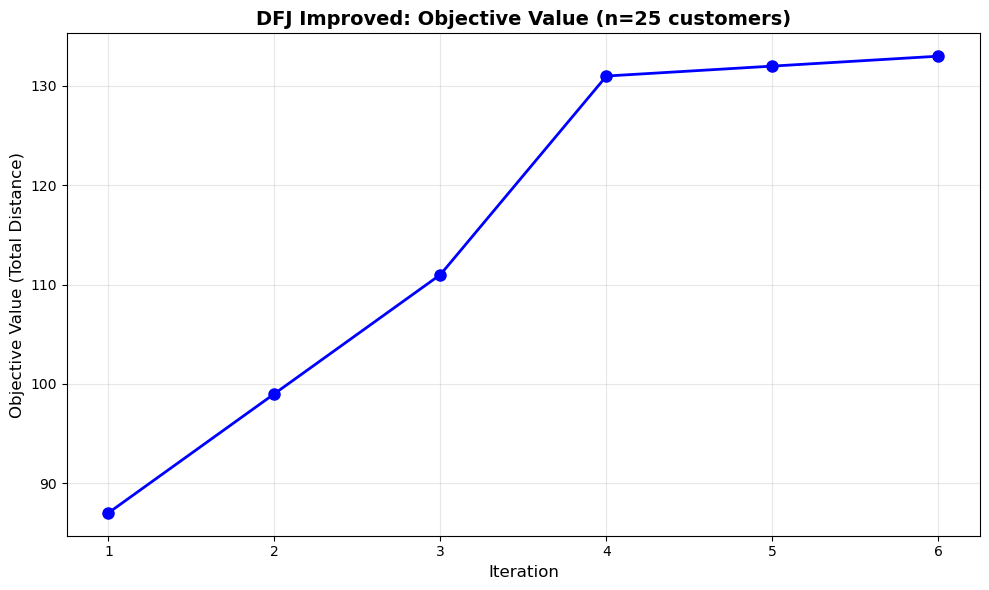

In [ ]:


iterations = list(iteration_results.keys())
objectives = list(iteration_results.values())

plt.figure(figsize=(10, 6))
plt.plot(iterations, objectives, 'b-o', linewidth=2, markersize=8)
plt.xlabel('Iteration', fontsize=12)
plt.ylabel('Objective Value (Total Distance)', fontsize=12)
plt.title(f'DFJ Improved: Objective Value (n=25 customers)', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.xticks(iterations)




plt.tight_layout()
plt.show()

